# 04 — Genetic Algorithm aplicado al ATSP

**Variante del TSP — Notebook 4 de 5**

El cromosoma sigue siendo una permutación, pero su fitness se calcula con una
matriz dirigida. Se mantiene **Order Crossover (OX)** para producir permutaciones
válidas y se usa una mutación mixta de intercambio o inserción.

## Qué se aprenderá
1. Codificación por permutaciones para ATSP.
2. Selección por torneo, elitismo, OX y mutación.
3. Conservación de diversidad mediante operadores mixtos.
4. Comparación para 10, 20, 50 y 100 ciudades.

## Semillas dinámicas de esta versión
- `MASTER_SEED = None` genera una variante nueva cada vez que se ejecuta todo.
- Cada tamaño utiliza semillas independientes y estas se imprimen antes de resolverlo.
- Para repetir una ejecución, copia la semilla maestra impresa y colócala en `MASTER_SEED`.


## 1. Variante estudiada: TSP asimétrico (ATSP)

En el TSP tradicional suele suponerse que la distancia es simétrica:

$$c_{ij}=c_{ji}.$$

En el **Asymmetric Traveling Salesman Problem (ATSP)** esta igualdad no se exige:

$$c_{ij}\neq c_{ji}.$$

Esto representa situaciones reales como calles de un solo sentido, pendientes,
peajes diferentes, viento, congestión o tiempos de viaje dependientes de la
dirección. Se busca una permutación de todas las ciudades que minimice

$$f(\pi)=\sum_{k=0}^{n-1}c_{\pi_k,\pi_{(k+1)\bmod n}}.$$

Los tres tamaños usados son **10, 20, 50 y 100 ciudades**. En cada ejecución se crea una **semilla maestra nueva** y, a partir de ella,
semillas independientes para las instancias y los componentes aleatorios. Todas
se imprimen y se guardan en las tablas. Para repetir un resultado basta con copiar
la semilla maestra mostrada y asignarla a `MASTER_SEED`.


In [ ]:
%matplotlib inline
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def make_atsp_instance(n, seed=42, asymmetry=0.40):
    """Crea coordenadas y una matriz de costos dirigida para un ATSP."""
    rng = np.random.default_rng(seed)
    coords = rng.uniform(0, 100, size=(n, 2))
    delta = coords[:, None, :] - coords[None, :, :]
    euclidean = np.sqrt((delta ** 2).sum(axis=2))

    directional_factor = 1.0 + asymmetry * rng.uniform(-1.0, 1.0, size=(n, n))
    D = euclidean * directional_factor
    np.fill_diagonal(D, np.inf)
    return coords, D


def tour_cost(tour, D):
    tour = np.asarray(tour, dtype=int)
    return float(D[tour, np.roll(tour, -1)].sum())


def validate_tour(tour, n):
    tour = np.asarray(tour, dtype=int)
    return len(tour) == n and np.array_equal(np.sort(tour), np.arange(n))


def nearest_neighbor(D, start=0):
    """Solución inicial rápida respetando los costos dirigidos."""
    n = len(D)
    unvisited = set(range(n))
    unvisited.remove(start)
    tour = [start]
    while unvisited:
        last = tour[-1]
        nxt = min(unvisited, key=lambda j: D[last, j])
        tour.append(nxt)
        unvisited.remove(nxt)
    return np.asarray(tour, dtype=int)


def random_tour(n, rng):
    """Fija la ciudad 0 al comienzo para eliminar rotaciones equivalentes."""
    return np.r_[0, rng.permutation(np.arange(1, n))]


def asymmetry_index(D):
    """Promedio relativo de |c_ij-c_ji| sobre los arcos fuera de la diagonal."""
    n = len(D)
    mask = ~np.eye(n, dtype=bool)
    forward = D[mask]
    reverse = D.T[mask]
    denom = np.maximum((forward + reverse) / 2.0, 1e-12)
    return float(np.mean(np.abs(forward - reverse) / denom))


def plot_directed_tour(coords, tour, title='', ax=None):
    """Dibuja el ciclo e indica su orientación con flechas."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    tour = np.asarray(tour, dtype=int)
    closed = np.r_[tour, tour[0]]
    xy = coords[closed]
    ax.plot(xy[:, 0], xy[:, 1], '-o', linewidth=1.3, markersize=4)
    dx = xy[1:, 0] - xy[:-1, 0]
    dy = xy[1:, 1] - xy[:-1, 1]
    ax.quiver(xy[:-1, 0], xy[:-1, 1], dx, dy,
              angles='xy', scale_units='xy', scale=1,
              width=0.003, alpha=0.65)
    if len(coords) <= 20:
        for i, (x, y) in enumerate(coords):
            ax.annotate(str(i), (x, y), xytext=(4, 4),
                        textcoords='offset points', fontsize=8)
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)
    return ax



MASTER_SEED = None

if MASTER_SEED is None:
    RUN_SEED = int(np.random.SeedSequence().generate_state(1, dtype=np.uint32)[0])
else:
    RUN_SEED = int(MASTER_SEED)

seed_rng = np.random.default_rng(RUN_SEED)
SIZES = [10, 20, 50, 100]


def next_seed():
    """Entrega una semilla uint32 independiente y compatible con NumPy."""
    return int(seed_rng.integers(0, 2**32, dtype=np.uint32))


INSTANCE_SEEDS = {n: next_seed() for n in SIZES}
START_SEEDS = {n: next_seed() for n in SIZES}
TEMPERATURE_SEEDS = {n: next_seed() for n in SIZES}
ALGORITHM_SEEDS = {n: next_seed() for n in SIZES}

INSTANCES = {
    n: make_atsp_instance(n, seed=INSTANCE_SEEDS[n], asymmetry=0.40)
    for n in SIZES
}

seed_table = pd.DataFrame({
    'n': SIZES,
    'semilla_instancia': [INSTANCE_SEEDS[n] for n in SIZES],
    'semilla_inicio': [START_SEEDS[n] for n in SIZES],
    'semilla_temperatura': [TEMPERATURE_SEEDS[n] for n in SIZES],
    'semilla_algoritmo': [ALGORITHM_SEEDS[n] for n in SIZES],
})

print('=' * 72)
print(f'SEMILLA MAESTRA DE ESTA EJECUCIÓN: {RUN_SEED}')
print('Para repetirla, asigna ese número a MASTER_SEED y ejecuta todo nuevamente.')
print('=' * 72)
display(seed_table)

for n, (_, D) in INSTANCES.items():
    print(
        f'n={n:3d} | semilla instancia={INSTANCE_SEEDS[n]:10d} | '
        f'asimetría={asymmetry_index(D):.3f} | '
        f'costo greedy={tour_cost(nearest_neighbor(D), D):.2f}'
    )


SEMILLA MAESTRA DE ESTA EJECUCIÓN: 171431868
Para repetirla, asigna ese número a MASTER_SEED y ejecuta todo nuevamente.


,n,semilla_instancia,semilla_inicio,semilla_temperatura,semilla_algoritmo
0,10,3615661755,736615390,2930446735,564582194
1,20,1726394334,322465293,3704188857,2938688703
2,50,4250773416,2509052362,618581774,2249319947
3,100,3904615836,3034870849,2806637883,3615213606


n= 10 | semilla instancia=3615661755 | asimetría=0.262 | costo greedy=362.34
n= 20 | semilla instancia=1726394334 | asimetría=0.283 | costo greedy=362.01
n= 50 | semilla instancia=4250773416 | asimetría=0.264 | costo greedy=662.65
n=100 | semilla instancia=3904615836 | asimetría=0.276 | costo greedy=980.25


## 2. Motor genético y operadores

El motor maximiza fitness. Para minimizar el costo dirigido se define
`fitness = -tour_cost`. Cada individuo se rota para dejar la ciudad 0 al inicio;
esto elimina representaciones equivalentes del mismo ciclo sin alterar su costo.


In [2]:
def normalize_zero(tour):
    tour = np.asarray(tour, dtype=int)
    pos = int(np.where(tour == 0)[0][0])
    return np.roll(tour, -pos)


def tournament_selection(population, fitness_values, rng, k=3):
    idx = rng.choice(len(population), size=k, replace=False)
    winner = idx[np.argmax([fitness_values[i] for i in idx])]
    return population[winner].copy()


def order_crossover(p1, p2, rng):
    n = len(p1)
    a, b = sorted(rng.choice(n, size=2, replace=False))

    def build(parent, donor):
        child = np.full(n, -1, dtype=int)
        child[a:b + 1] = parent[a:b + 1]
        used = set(child[a:b + 1].tolist())
        donor_order = list(donor[b + 1:]) + list(donor[:b + 1])
        positions = list(range(b + 1, n)) + list(range(0, b + 1))
        pos_iter = iter(positions)
        for city in donor_order:
            if int(city) not in used:
                child[next(pos_iter)] = city
        return normalize_zero(child)

    return build(p1, p2), build(p2, p1)


def mixed_mutation(tour, rng, rate=0.25):
    child = tour.copy()
    if rng.random() >= rate:
        return child

    n = len(child)
    i, j = sorted(rng.choice(np.arange(1, n), size=2, replace=False))
    if rng.random() < 0.5:
        child[i], child[j] = child[j], child[i]
    else:
        city = child[j]
        child = np.delete(child, j)
        child = np.insert(child, i, city)
    return normalize_zero(child)


def genetic_algorithm(initial_population, fitness, n_gen=200,
                      elitism=3, crossover_rate=0.9,
                      mutation_rate=0.25, tournament_k=3, seed=0):
    rng = np.random.default_rng(seed)
    population = [ind.copy() for ind in initial_population]
    pop_size = len(population)
    fitness_values = [fitness(ind) for ind in population]

    best_idx = int(np.argmax(fitness_values))
    best = population[best_idx].copy()
    best_fit = fitness_values[best_idx]
    history = [best_fit]

    for _ in range(n_gen):
        order = np.argsort(fitness_values)[::-1]
        new_population = [population[i].copy() for i in order[:elitism]]

        while len(new_population) < pop_size:
            p1 = tournament_selection(population, fitness_values, rng, tournament_k)
            p2 = tournament_selection(population, fitness_values, rng, tournament_k)

            if rng.random() < crossover_rate:
                c1, c2 = order_crossover(p1, p2, rng)
            else:
                c1, c2 = p1.copy(), p2.copy()

            c1 = mixed_mutation(c1, rng, mutation_rate)
            c2 = mixed_mutation(c2, rng, mutation_rate)
            new_population.append(c1)
            if len(new_population) < pop_size:
                new_population.append(c2)

        population = new_population
        fitness_values = [fitness(ind) for ind in population]
        generation_best = int(np.argmax(fitness_values))

        if fitness_values[generation_best] > best_fit:
            best = population[generation_best].copy()
            best_fit = fitness_values[generation_best]
        history.append(best_fit)

    return best, best_fit, history


## 3. Ejemplo principal: 20 ciudades

Semilla maestra          : 171431868
Semilla instancia        : 1726394334
Semilla población inicial: 322465293
Semilla algoritmo        : 2938688703
Mejor costo GA : 351.354
Costo greedy   : 362.007
Ruta válida    : True


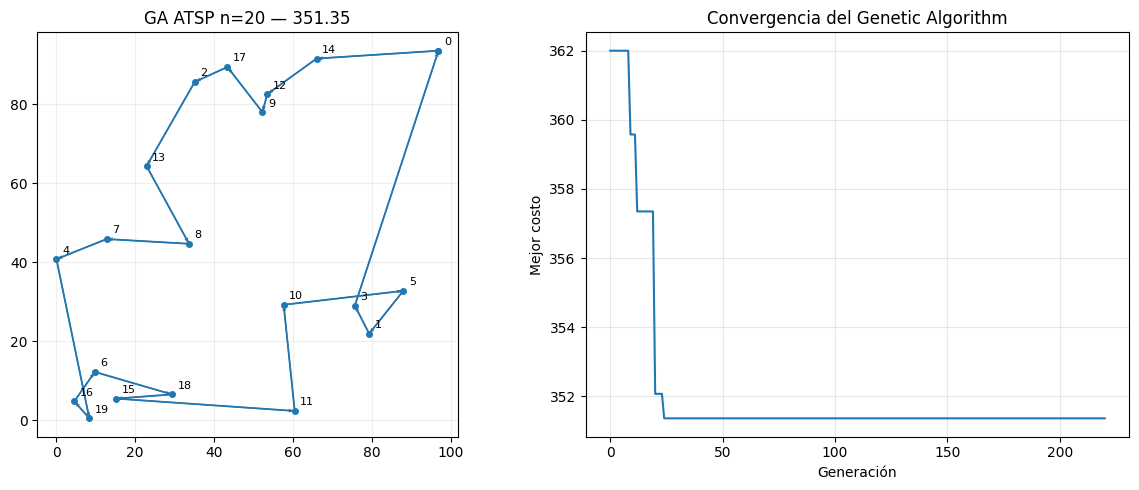

In [3]:
coords20, D20 = INSTANCES[20]
start_seed20 = START_SEEDS[20]
algorithm_seed20 = ALGORITHM_SEEDS[20]
rng20 = np.random.default_rng(start_seed20)
pop20 = [nearest_neighbor(D20)] + [random_tour(20, rng20) for _ in range(119)]
fitness20 = lambda tour: -tour_cost(tour, D20)

print(f'Semilla maestra          : {RUN_SEED}')
print(f'Semilla instancia        : {INSTANCE_SEEDS[20]}')
print(f'Semilla población inicial: {start_seed20}')
print(f'Semilla algoritmo        : {algorithm_seed20}')

best20, fit20, hist20 = genetic_algorithm(
    pop20, fitness20, n_gen=220,
    elitism=4, crossover_rate=0.9,
    mutation_rate=0.30, tournament_k=3,
    seed=algorithm_seed20,
)
value20 = -fit20

print(f'Mejor costo GA : {value20:.3f}')
print(f'Costo greedy   : {tour_cost(nearest_neighbor(D20), D20):.3f}')
print(f'Ruta válida    : {validate_tour(best20, 20)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_directed_tour(coords20, best20, f'GA ATSP n=20 — {value20:.2f}', ax=axes[0])
axes[1].plot([-x for x in hist20])
axes[1].set_title('Convergencia del Genetic Algorithm')
axes[1].set_xlabel('Generación')
axes[1].set_ylabel('Mejor costo')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Entradas de 10, 20, 50 y 100 ciudades

In [4]:
GA_CONFIG = {
    10: {'population': 80, 'generations': 140, 'mutation': 0.25},
    20: {'population': 120, 'generations': 220, 'mutation': 0.30},
    50: {'population': 180, 'generations': 320, 'mutation': 0.35},
    100: {'population': 220, 'generations': 400, 'mutation': 0.38},
}

ga_results = []
ga_histories = {}
ga_solutions = {}

for execution_id, n in enumerate(SIZES, start=1):
    coords, D = INSTANCES[n]
    cfg = GA_CONFIG[n]
    start_seed = START_SEEDS[n]
    algorithm_seed = ALGORITHM_SEEDS[n]
    rng = np.random.default_rng(start_seed)
    population = [nearest_neighbor(D)] + [
        random_tour(n, rng) for _ in range(cfg['population'] - 1)
    ]
    fitness = lambda tour, D=D: -tour_cost(tour, D)
    initial_best = min(tour_cost(ind, D) for ind in population)

    print('\n' + '-' * 72)
    print(f'Ejecución {execution_id}/{len(SIZES)} — Genetic Algorithm — n={n}')
    print(f'Semilla de instancia         : {INSTANCE_SEEDS[n]}')
    print(f'Semilla de población inicial : {start_seed}')
    print(f'Semilla de algoritmo         : {algorithm_seed}')

    t0 = time.perf_counter()
    best, best_fit, history = genetic_algorithm(
        population,
        fitness,
        n_gen=cfg['generations'],
        elitism=4,
        crossover_rate=0.90,
        mutation_rate=cfg['mutation'],
        tournament_k=3,
        seed=algorithm_seed,
    )
    elapsed = time.perf_counter() - t0
    value = -best_fit

    ga_solutions[n] = best
    ga_histories[n] = [-x for x in history]
    ga_results.append({
        'ejecucion': execution_id,
        'n': n,
        'semilla_maestra': RUN_SEED,
        'semilla_instancia': INSTANCE_SEEDS[n],
        'semilla_poblacion': start_seed,
        'semilla_algoritmo': algorithm_seed,
        'mejor_inicial': initial_best,
        'mejor_final': value,
        'mejora_%': 100 * (initial_best - value) / initial_best,
        'poblacion': cfg['population'],
        'generaciones': cfg['generations'],
        'tiempo_s': elapsed,
    })

    print(f'Mejor costo          : {value:.3f}')
    print(f'Tiempo               : {elapsed:.3f} s')


ga_df = pd.DataFrame(ga_results)
display(ga_df.round({
    'mejor_inicial': 2,
    'mejor_final': 2,
    'mejora_%': 2,
    'tiempo_s': 3,
}))



------------------------------------------------------------------------
Ejecución 1/4 — Genetic Algorithm — n=10
Semilla de instancia         : 3615661755
Semilla de población inicial : 736615390
Semilla de algoritmo         : 564582194
Mejor costo          : 275.452
Tiempo               : 8.289 s

------------------------------------------------------------------------
Ejecución 2/4 — Genetic Algorithm — n=20
Semilla de instancia         : 1726394334
Semilla de población inicial : 322465293
Semilla de algoritmo         : 2938688703
Mejor costo          : 351.354
Tiempo               : 17.977 s

------------------------------------------------------------------------
Ejecución 3/4 — Genetic Algorithm — n=50
Semilla de instancia         : 4250773416
Semilla de población inicial : 2509052362
Semilla de algoritmo         : 2249319947
Mejor costo          : 776.223
Tiempo               : 48.135 s


,ejecucion,n,semilla_maestra,semilla_instancia,semilla_poblacion,semilla_algoritmo,mejor_inicial,mejor_final,mejora_%,poblacion,generaciones,tiempo_s
0,1,10,171431868,3615661755,736615390,564582194,362.34,275.45,23.98,80,140,8.289
1,2,20,171431868,1726394334,322465293,2938688703,362.01,351.35,2.94,120,220,17.977
2,3,50,171431868,4250773416,2509052362,2249319947,662.65,608.97,8.10,180,320,22.905
3,4,100,171431868,3904615836,3034870849,3615213606,980.25,776.22,20.81,220,400,48.135


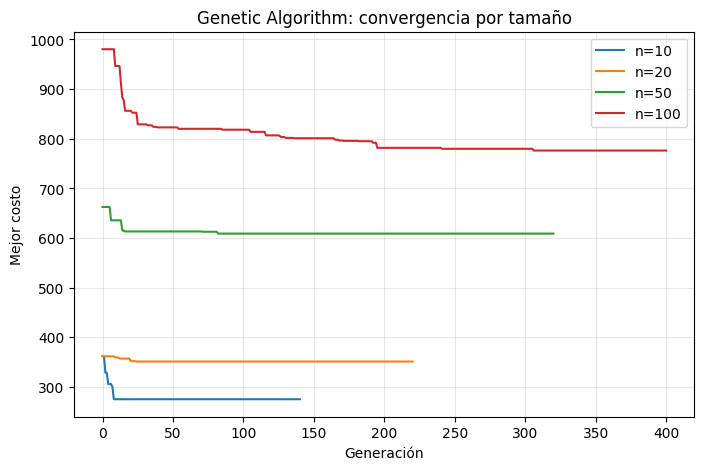

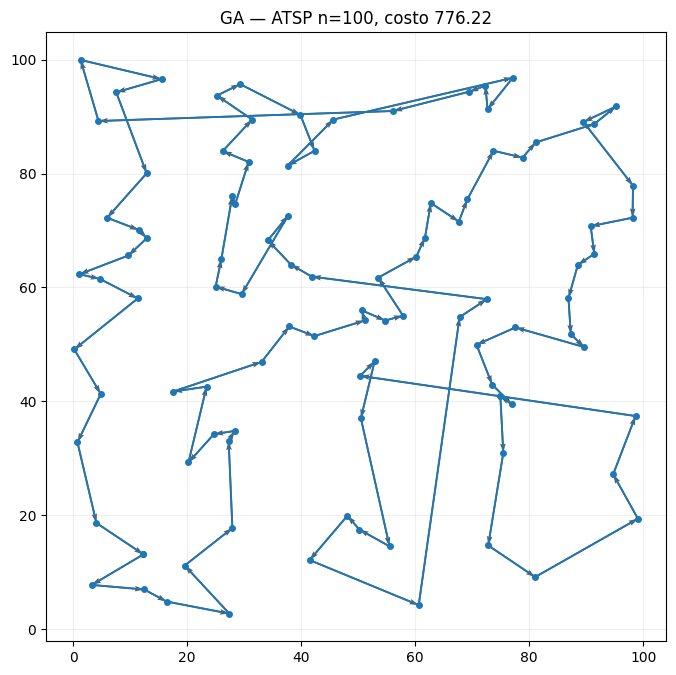

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for n in SIZES:
    ax.plot(ga_histories[n], label=f'n={n}')
ax.set_title('Genetic Algorithm: convergencia por tamaño')
ax.set_xlabel('Generación')
ax.set_ylabel('Mejor costo')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

coords100, D100 = INSTANCES[100]
fig, ax = plt.subplots(figsize=(8, 8))
plot_directed_tour(
    coords100,
    ga_solutions[100],
    f'GA — ATSP n=100, costo {tour_cost(ga_solutions[100], D100):.2f}',
    ax=ax,
)
plt.show()


## 5. Parámetros, trade-offs y complejidad

- El costo por generación es aproximadamente
  $O(\text{población}\times n)$ para evaluar los individuos, además del costo de
  selección y operadores.
- Mayor población conserva diversidad, pero aumenta el tiempo.
- Mutación insuficiente produce convergencia prematura; una tasa excesiva
  convierte la búsqueda en casi aleatoria.
- OX conserva orden relativo, mientras que intercambio e inserción permiten
  explorar nuevas relaciones dirigidas.

## Ejercicios
1. Implementar PMX y comparar con OX.
2. Medir diversidad de la población en cada generación.
3. Agregar una mejora local al mejor hijo (algoritmo memético).
4. Comparar torneo de tamaño 2, 3 y 5.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def crear_gantt_ruta(
    ruta,
    D,
    algoritmo,
    n,
    semilla_instancia,
    semilla_algoritmo=None,
    semillas_adicionales=None,
    guardar=False,
    nombre_archivo=None,
    mostrar_tabla=True
):
    
    ruta = np.asarray(ruta, dtype=int)
    D = np.asarray(D, dtype=float)

    if ruta.ndim != 1:
        raise ValueError("La ruta debe ser un arreglo unidimensional.")

    if len(ruta) != n:
        raise ValueError(
            f"La ruta tiene {len(ruta)} ciudades, pero se esperaba n={n}."
        )

    if len(np.unique(ruta)) != n:
        raise ValueError(
            "La ruta contiene ciudades repetidas."
        )

    if not np.array_equal(np.sort(ruta), np.arange(n)):
        raise ValueError(
            "La ruta no contiene exactamente las ciudades entre 0 y n-1."
        )

    if D.shape != (n, n):
        raise ValueError(
            f"La matriz D debe tener dimensiones ({n}, {n})."
        )


    ruta_cerrada = np.append(ruta, ruta[0])

    origenes = ruta_cerrada[:-1]
    destinos = ruta_cerrada[1:]

    costos_tramos = np.array([
        D[origen, destino]
        for origen, destino in zip(origenes, destinos)
    ])

    if not np.all(np.isfinite(costos_tramos)):
        raise ValueError(
            "La ruta contiene desplazamientos con costo infinito."
        )

    inicio_acumulado = np.concatenate([
        [0.0],
        np.cumsum(costos_tramos)[:-1]
    ])

    costo_acumulado = np.cumsum(costos_tramos)
    costo_total = float(costo_acumulado[-1])

    percentil_75 = float(
        np.percentile(costos_tramos, 75)
    )

    df_gantt = pd.DataFrame({
        "paso": np.arange(1, n + 1),
        "origen": origenes,
        "destino": destinos,
        "tramo": [
            f"{paso:03d}. Ciudad {origen} → Ciudad {destino}"
            for paso, origen, destino in zip(
                np.arange(1, n + 1),
                origenes,
                destinos
            )
        ],
        "inicio_acumulado": inicio_acumulado,
        "costo_tramo": costos_tramos,
        "costo_acumulado": costo_acumulado,
        "porcentaje_total": (
            costos_tramos / costo_total
        ) * 100,
        "tramo_costoso": (
            costos_tramos >= percentil_75
        )
    })

    altura = max(
        7,
        min(34, 4 + n * 0.29)
    )

    fig, ax = plt.subplots(
        figsize=(17, altura)
    )

    posiciones_y = np.arange(n)

    barras = ax.barh(
        posiciones_y,
        df_gantt["costo_tramo"],
        left=df_gantt["inicio_acumulado"],
        edgecolor="black",
        linewidth=0.7
    )

    for indice, barra in enumerate(barras):

        es_costoso = bool(
            df_gantt.loc[indice, "tramo_costoso"]
        )

        if es_costoso:
            barra.set_hatch("////")
            barra.set_linewidth(1.3)

        costo = float(
            df_gantt.loc[indice, "costo_tramo"]
        )

        inicio = float(
            df_gantt.loc[
                indice,
                "inicio_acumulado"
            ]
        )

        mostrar_valor = (
            n <= 20
            or es_costoso
        )

        if mostrar_valor:
            ax.text(
                inicio + costo / 2,
                indice,
                f"{costo:.1f}",
                ha="center",
                va="center",
                fontsize=7
            )

    ax.axvline(
        costo_total,
        linestyle="--",
        linewidth=1.6
    )

    ax.set_xlim(
        0,
        costo_total * 1.05
    )

    ax.set_yticks(posiciones_y)

    ax.set_yticklabels(
        df_gantt["tramo"],
        fontsize=7 if n >= 50 else 8
    )

    ax.invert_yaxis()

    ax.set_xlabel(
        "Costo acumulado de la ruta"
    )

    ax.set_ylabel(
        "Secuencia de desplazamientos"
    )

    texto_semillas = (
        f"Semilla instancia: {semilla_instancia}"
    )

    if semilla_algoritmo is not None:
        texto_semillas += (
            f" | Semilla algoritmo: "
            f"{semilla_algoritmo}"
        )

    if semillas_adicionales:
        for nombre, valor in semillas_adicionales.items():
            texto_semillas += (
                f" | {nombre}: {valor}"
            )

    ax.set_title(
        f"{algoritmo} — Carta Gantt de la mejor ruta ATSP\n"
        f"n={n} | costo total={costo_total:.2f}\n"
        f"{texto_semillas}",
        fontsize=13,
        pad=14
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    leyenda = [
        Patch(
            fill=False,
            edgecolor="black",
            hatch="////",
            label=(
                f"Tramo costoso ≥ P75 "
                f"({percentil_75:.2f})"
            )
        ),
        Line2D(
            [0],
            [0],
            linestyle="--",
            label=(
                f"Costo total: "
                f"{costo_total:.2f}"
            )
        )
    ]

    ax.legend(
        handles=leyenda,
        loc="lower right"
    )

    plt.tight_layout()

    if guardar:

        if nombre_archivo is None:
            nombre_normalizado = (
                algoritmo
                .lower()
                .replace(" ", "_")
                .replace("&", "and")
            )

            nombre_archivo = (
                f"gantt_{nombre_normalizado}_n{n}.png"
            )

        fig.savefig(
            nombre_archivo,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            f"Gráfico guardado: {nombre_archivo}"
        )

    print("\n" + "=" * 72)
    print(f"ALGORITMO: {algoritmo}")
    print(f"NÚMERO DE CIUDADES: {n}")
    print(f"SEMILLA DE INSTANCIA: {semilla_instancia}")

    if semilla_algoritmo is not None:
        print(
            f"SEMILLA DE ALGORITMO: "
            f"{semilla_algoritmo}"
        )

    if semillas_adicionales:
        for nombre, valor in semillas_adicionales.items():
            print(
                f"{nombre.upper()}: {valor}"
            )

    print(f"COSTO TOTAL: {costo_total:.3f}")
    print(
        f"COSTO PROMEDIO POR TRAMO: "
        f"{costos_tramos.mean():.3f}"
    )
    print(
        f"TRAMO DE MAYOR COSTO: "
        f"{costos_tramos.max():.3f}"
    )
    print(
        f"PERCENTIL 75: "
        f"{percentil_75:.3f}"
    )

    print("\nRuta encontrada:")
    print(
        " → ".join(
            map(str, ruta_cerrada)
        )
    )

    if mostrar_tabla:

        columnas = [
            "paso",
            "origen",
            "destino",
            "costo_tramo",
            "costo_acumulado",
            "porcentaje_total",
            "tramo_costoso"
        ]

        display(
            df_gantt[columnas].round({
                "costo_tramo": 3,
                "costo_acumulado": 3,
                "porcentaje_total": 2
            })
        )

        print("\nCinco tramos de mayor costo:")

        display(
            df_gantt.nlargest(
                5,
                "costo_tramo"
            )[columnas].round({
                "costo_tramo": 3,
                "costo_acumulado": 3,
                "porcentaje_total": 2
            })
        )

    return df_gantt, fig, ax


################################################################################
CARTA GANTT GENETIC ALGORITHM — n=10
Semilla instancia: 3615661755
Semilla población inicial: 736615390
Semilla algoritmo: 564582194
Gráfico guardado: gantt_genetic_algorithm_n10_instance_seed_3615661755_population_seed_736615390_algorithm_seed_564582194.png

ALGORITMO: Genetic Algorithm
NÚMERO DE CIUDADES: 10
SEMILLA DE INSTANCIA: 3615661755
SEMILLA DE ALGORITMO: 564582194
SEMILLA POBLACIÓN: 736615390
POBLACIÓN: 80
GENERACIONES: 140
COSTO TOTAL: 275.452
COSTO PROMEDIO POR TRAMO: 27.545
TRAMO DE MAYOR COSTO: 57.122
PERCENTIL 75: 34.367

Ruta encontrada:
0 → 2 → 7 → 4 → 1 → 6 → 8 → 3 → 9 → 5 → 0


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
0,1,0,2,12.135,12.135,4.41,False
1,2,2,7,30.132,42.267,10.94,False
2,3,7,4,31.711,73.977,11.51,False
3,4,4,1,22.606,96.583,8.21,False
4,5,1,6,35.252,131.835,12.80,True
5,6,6,8,22.519,154.354,8.18,False
6,7,8,3,35.599,189.953,12.92,True
7,8,3,9,10.434,200.387,3.79,False
8,9,9,5,57.122,257.509,20.74,True
9,10,5,0,17.943,275.452,6.51,False



Cinco tramos de mayor costo:


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
8,9,9,5,57.122,257.509,20.74,True
6,7,8,3,35.599,189.953,12.92,True
4,5,1,6,35.252,131.835,12.80,True
2,3,7,4,31.711,73.977,11.51,False
1,2,2,7,30.132,42.267,10.94,False


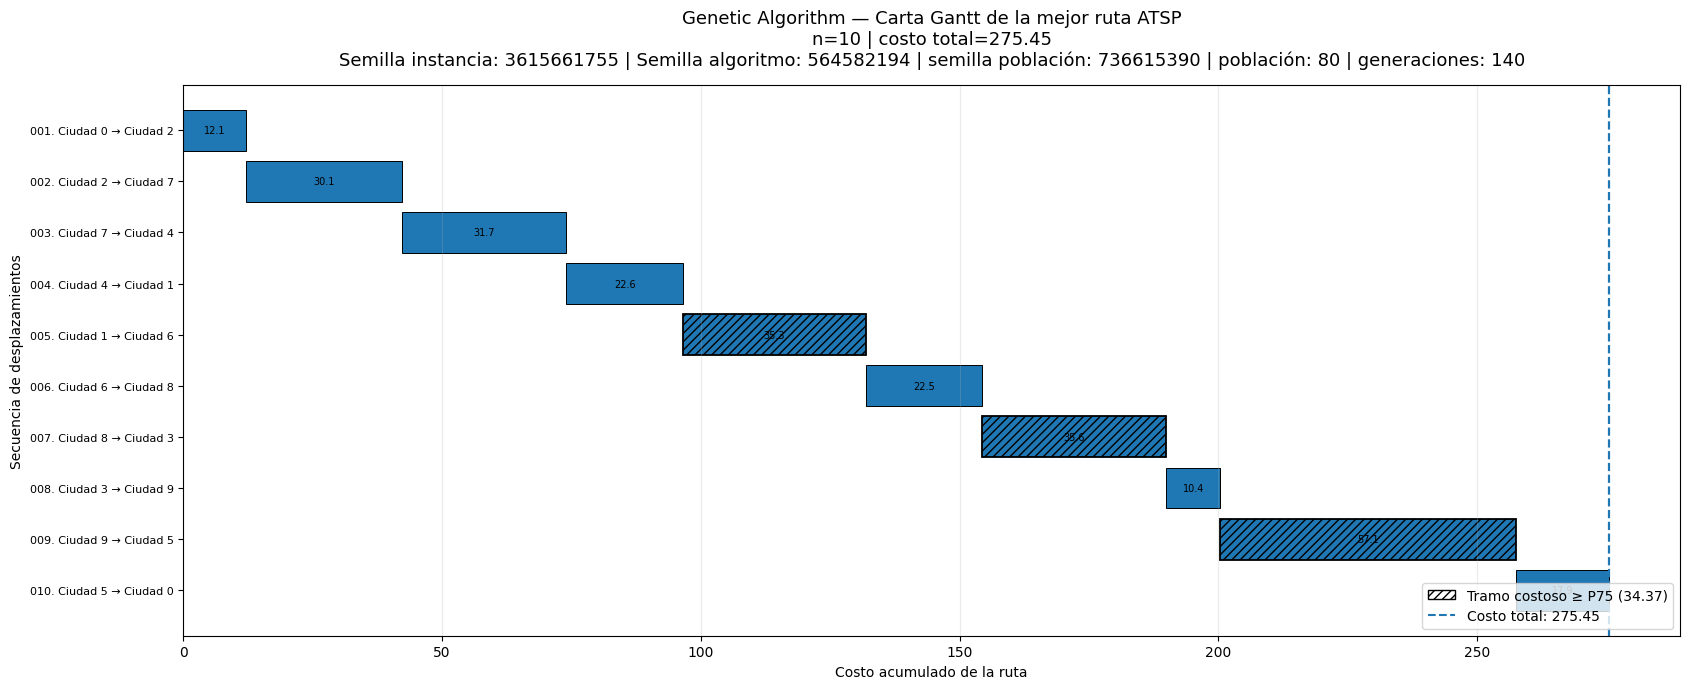


################################################################################
CARTA GANTT GENETIC ALGORITHM — n=20
Semilla instancia: 1726394334
Semilla población inicial: 322465293
Semilla algoritmo: 2938688703
Gráfico guardado: gantt_genetic_algorithm_n20_instance_seed_1726394334_population_seed_322465293_algorithm_seed_2938688703.png

ALGORITMO: Genetic Algorithm
NÚMERO DE CIUDADES: 20
SEMILLA DE INSTANCIA: 1726394334
SEMILLA DE ALGORITMO: 2938688703
SEMILLA POBLACIÓN: 322465293
POBLACIÓN: 120
GENERACIONES: 220
COSTO TOTAL: 351.354
COSTO PROMEDIO POR TRAMO: 17.568
TRAMO DE MAYOR COSTO: 47.939
PERCENTIL 75: 21.147

Ruta encontrada:
0 → 14 → 12 → 9 → 17 → 2 → 13 → 8 → 7 → 4 → 19 → 16 → 6 → 18 → 15 → 11 → 10 → 5 → 1 → 3 → 0


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
0,1,0,14,20.884,20.884,5.94,False
1,2,14,12,18.650,39.534,5.31,False
2,3,12,9,4.680,44.214,1.33,False
3,4,9,17,12.155,56.368,3.46,False
4,5,17,2,10.383,66.751,2.96,False
5,6,2,13,14.819,81.570,4.22,False
6,7,13,8,21.937,103.508,6.24,True
7,8,8,7,19.407,122.914,5.52,False
8,9,7,4,13.968,136.882,3.98,False
9,10,4,19,29.298,166.181,8.34,True



Cinco tramos de mayor costo:


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
19,20,3,0,47.939,351.354,13.64,True
14,15,15,11,30.298,245.123,8.62,True
9,10,4,19,29.298,166.181,8.34,True
16,17,10,5,25.524,286.927,7.26,True
6,7,13,8,21.937,103.508,6.24,True


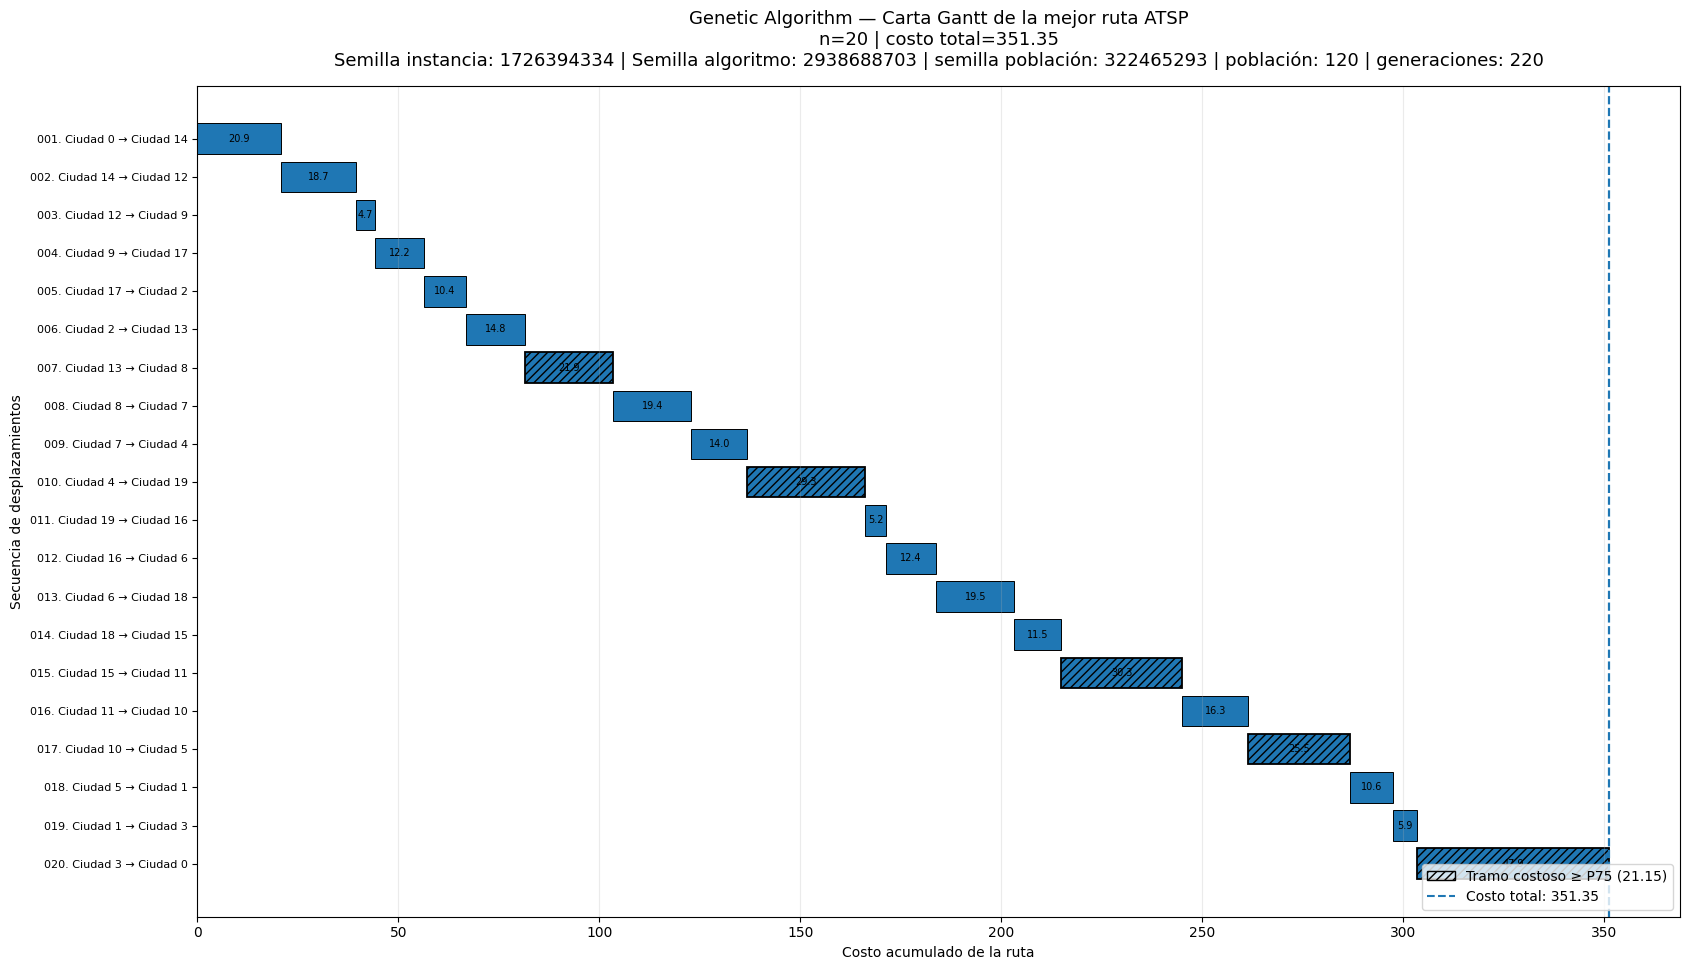


################################################################################
CARTA GANTT GENETIC ALGORITHM — n=50
Semilla instancia: 4250773416
Semilla población inicial: 2509052362
Semilla algoritmo: 2249319947
Gráfico guardado: gantt_genetic_algorithm_n50_instance_seed_4250773416_population_seed_2509052362_algorithm_seed_2249319947.png

ALGORITMO: Genetic Algorithm
NÚMERO DE CIUDADES: 50
SEMILLA DE INSTANCIA: 4250773416
SEMILLA DE ALGORITMO: 2249319947
SEMILLA POBLACIÓN: 2509052362
POBLACIÓN: 180
GENERACIONES: 320
COSTO TOTAL: 608.974
COSTO PROMEDIO POR TRAMO: 12.179
TRAMO DE MAYOR COSTO: 65.320
PERCENTIL 75: 13.736

Ruta encontrada:
0 → 8 → 47 → 16 → 30 → 17 → 21 → 43 → 12 → 32 → 14 → 13 → 36 → 40 → 29 → 4 → 38 → 49 → 34 → 23 → 39 → 25 → 41 → 5 → 42 → 15 → 37 → 10 → 28 → 3 → 24 → 1 → 6 → 20 → 18 → 44 → 45 → 27 → 22 → 35 → 26 → 48 → 11 → 31 → 33 → 7 → 19 → 2 → 46 → 9 → 0


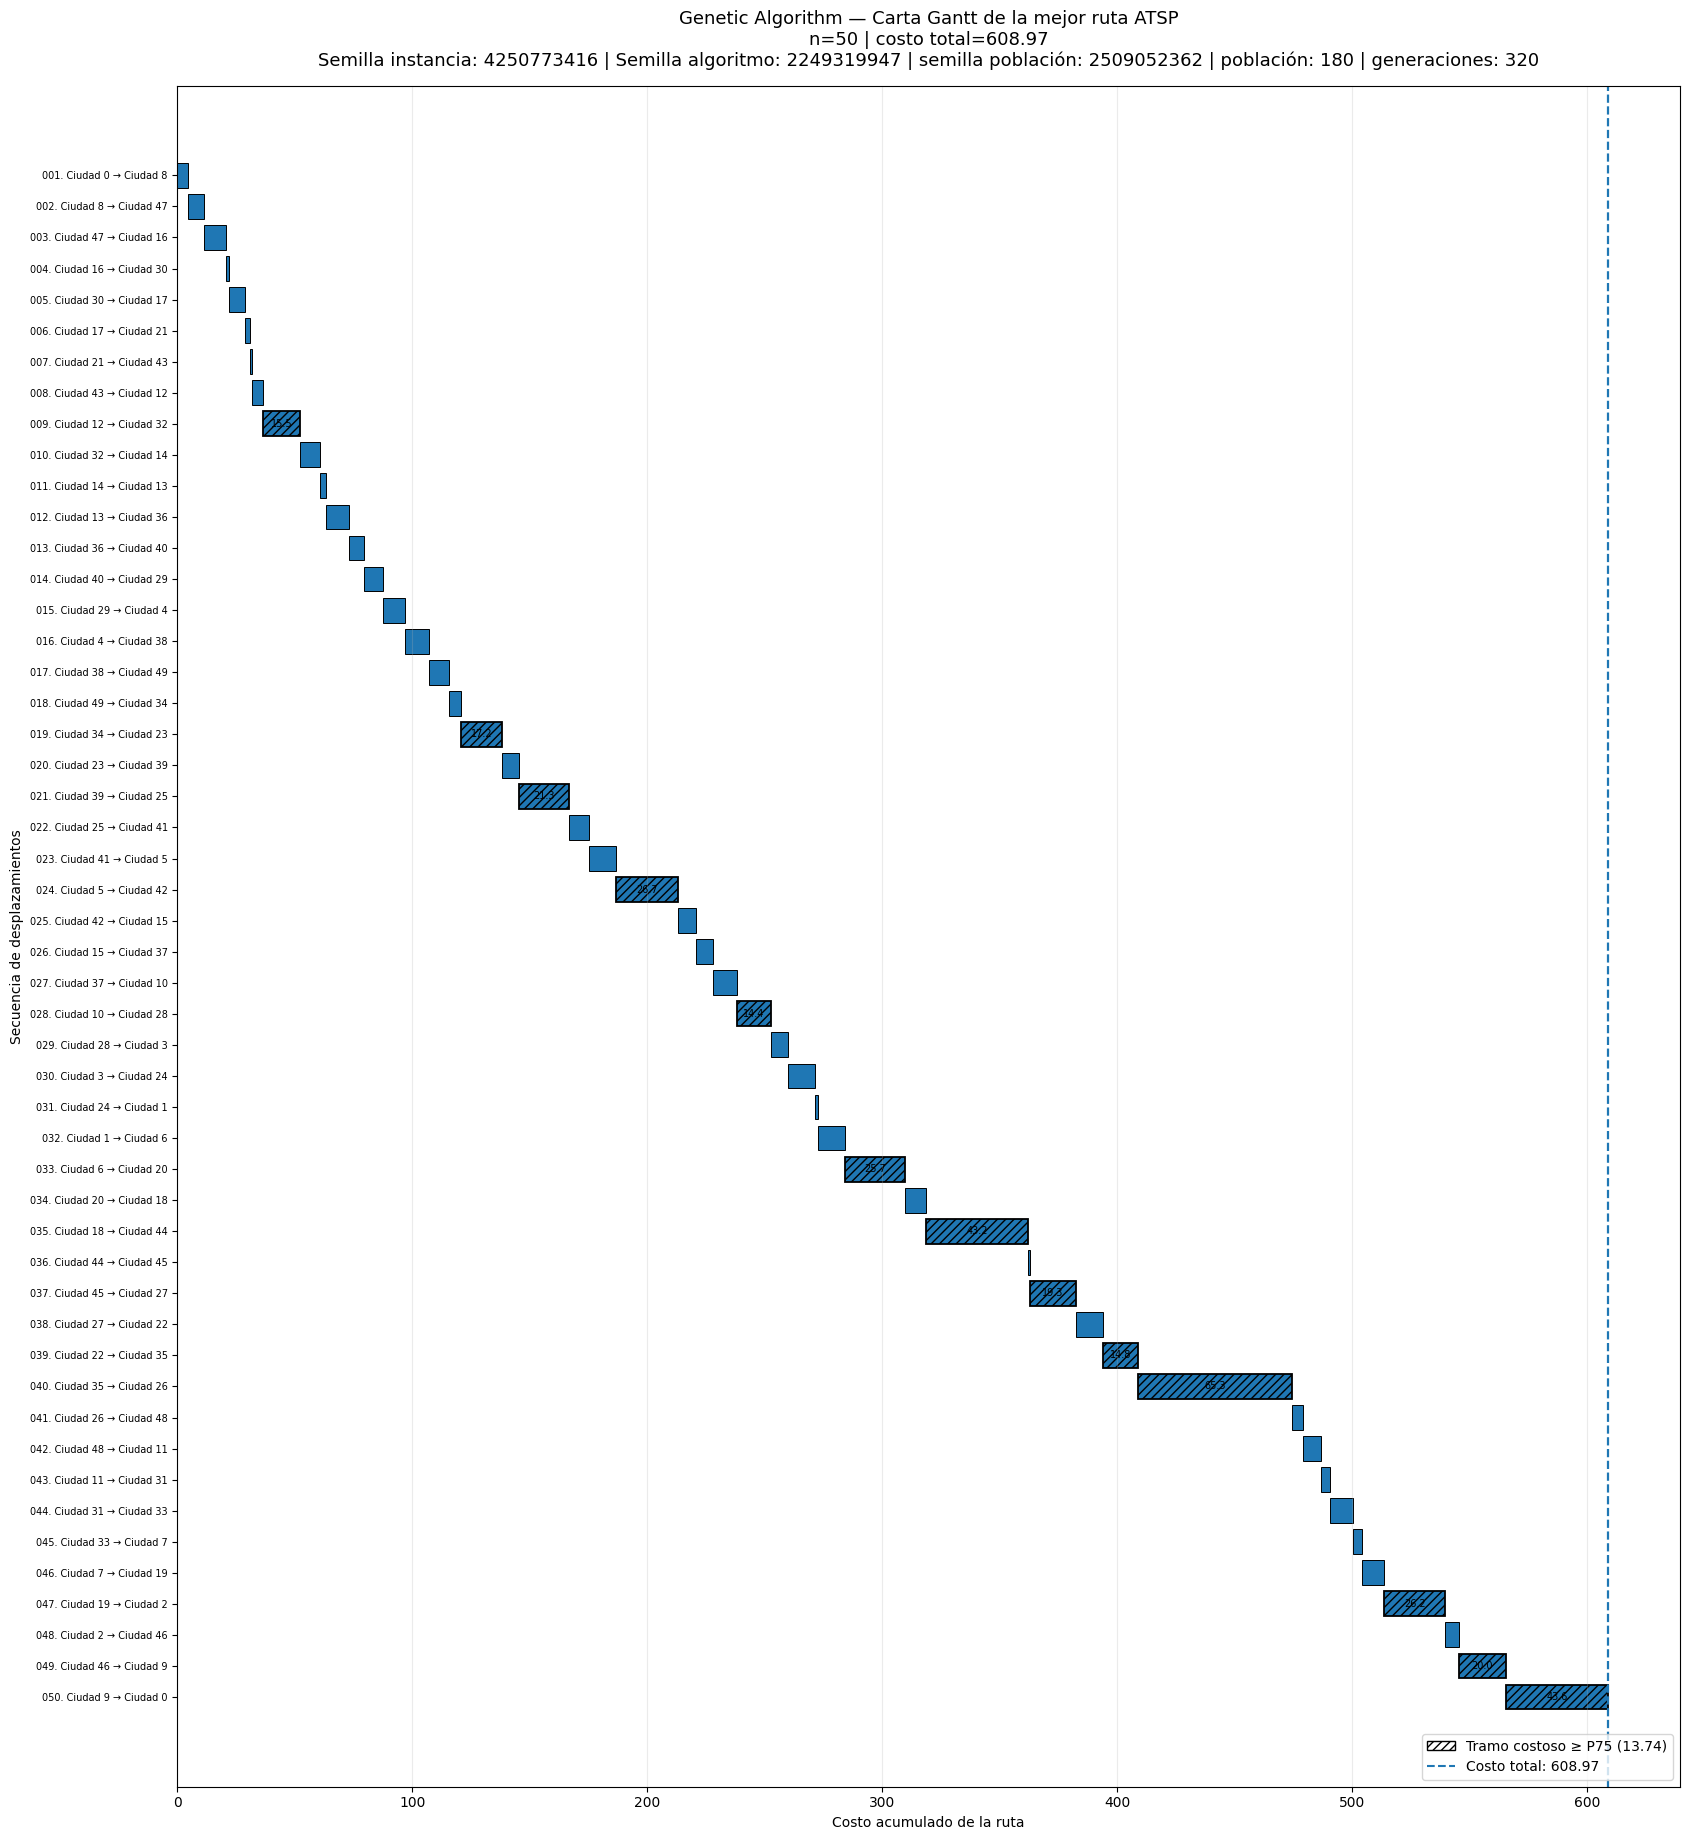


################################################################################
CARTA GANTT GENETIC ALGORITHM — n=100
Semilla instancia: 3904615836
Semilla población inicial: 3034870849
Semilla algoritmo: 3615213606
Gráfico guardado: gantt_genetic_algorithm_n100_instance_seed_3904615836_population_seed_3034870849_algorithm_seed_3615213606.png

ALGORITMO: Genetic Algorithm
NÚMERO DE CIUDADES: 100
SEMILLA DE INSTANCIA: 3904615836
SEMILLA DE ALGORITMO: 3615213606
SEMILLA POBLACIÓN: 3034870849
POBLACIÓN: 220
GENERACIONES: 400
COSTO TOTAL: 776.223
COSTO PROMEDIO POR TRAMO: 7.762
TRAMO DE MAYOR COSTO: 31.332
PERCENTIL 75: 9.376

Ruta encontrada:
0 → 96 → 90 → 43 → 58 → 94 → 35 → 48 → 77 → 83 → 60 → 22 → 16 → 91 → 75 → 54 → 46 → 30 → 98 → 5 → 99 → 26 → 71 → 85 → 13 → 17 → 47 → 82 → 11 → 40 → 45 → 81 → 89 → 3 → 7 → 69 → 29 → 76 → 28 → 84 → 72 → 57 → 65 → 78 → 67 → 88 → 8 → 59 → 6 → 93 → 21 → 9 → 80 → 42 → 50 → 2 → 61 → 70 → 25 → 53 → 38 → 14 → 51 → 15 → 68 → 41 → 39 → 95 → 55 → 74 → 36 → 23 

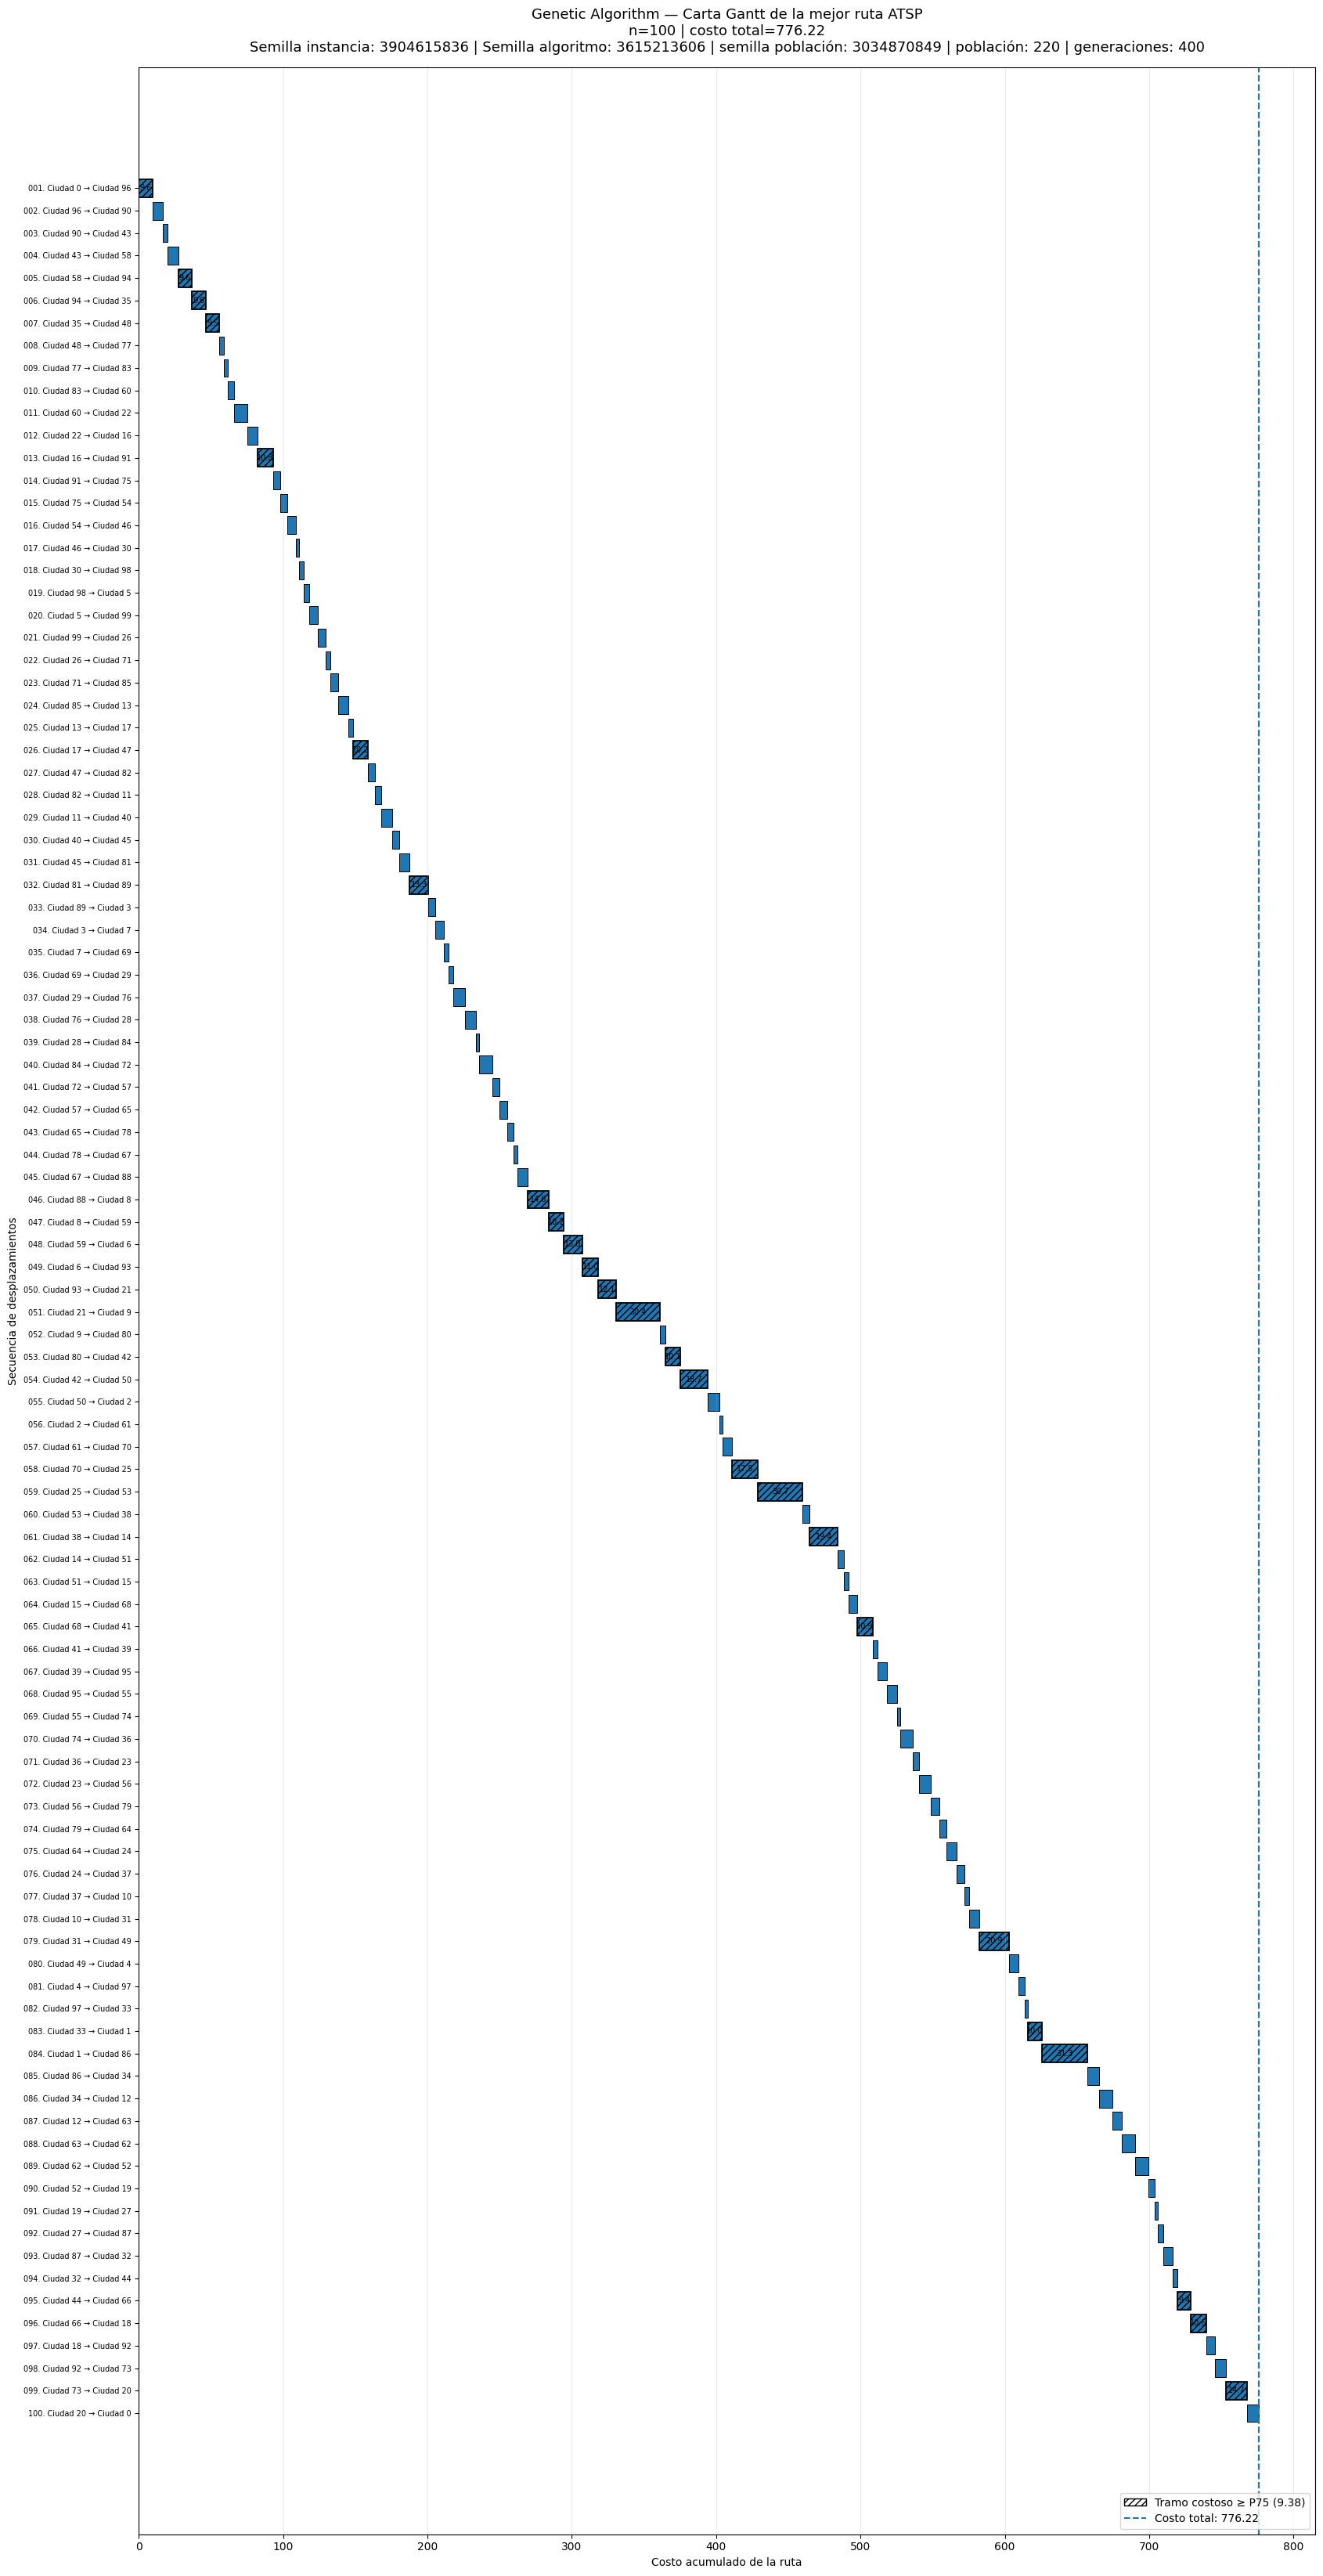

In [7]:
ga_gantt = {}

for n in SIZES:

    coords, D = INSTANCES[n]
    mejor_ruta = ga_solutions[n]

    print("\n" + "#" * 80)
    print(f"CARTA GANTT GENETIC ALGORITHM — n={n}")
    print(
        f"Semilla instancia: "
        f"{INSTANCE_SEEDS[n]}"
    )
    print(
        f"Semilla población inicial: "
        f"{START_SEEDS[n]}"
    )
    print(
        f"Semilla algoritmo: "
        f"{ALGORITHM_SEEDS[n]}"
    )

    df_gantt, fig, ax = crear_gantt_ruta(
        ruta=mejor_ruta,
        D=D,
        algoritmo="Genetic Algorithm",
        n=n,
        semilla_instancia=INSTANCE_SEEDS[n],
        semilla_algoritmo=ALGORITHM_SEEDS[n],
        semillas_adicionales={
            "semilla población": START_SEEDS[n],
            "población": GA_CONFIG[n]["population"],
            "generaciones": GA_CONFIG[n]["generations"]
        },
        guardar=True,
        nombre_archivo=(
            f"gantt_genetic_algorithm_n{n}_"
            f"instance_seed_{INSTANCE_SEEDS[n]}_"
            f"population_seed_{START_SEEDS[n]}_"
            f"algorithm_seed_{ALGORITHM_SEEDS[n]}.png"
        ),
        mostrar_tabla=(n <= 20)
    )

    ga_gantt[n] = df_gantt

    plt.show()